In [ ]:
!pip install tensorflow

In [1]:
# ==============================
# 1️⃣ IMPORTS
# ==============================
import os
import random
import shutil
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
# ==============================
# 2️⃣ CONFIGURATION
# ==============================
BASE_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\FinalDataset\fd\fd\Rotation\Gaussian"  # CHANGE THIS
WORK_DIR = r"C:\CODING\AI\PROJECTS\HC\Models\Alexnet"  # New folder for sampled data

IMG_SIZE = (128, 128)  # AlexNet typically uses 227x227 but we scale down for speed
BATCH_SIZE = 16
MAX_IMAGES_PER_CLASS = 200  # Limit per class for faster training
EPOCHS = 15


In [3]:
# ==============================
# 3️⃣ FUNCTION: SAMPLE DATASET (DOESN'T DELETE ORIGINAL)
# ==============================
def sample_dataset(src_dir, dest_dir, max_per_class):
    os.makedirs(dest_dir, exist_ok=True)

    for split in ['train', 'val', 'test']:
        for cls in os.listdir(os.path.join(src_dir, split)):
            src_cls_dir = os.path.join(src_dir, split, cls)
            dest_cls_dir = os.path.join(dest_dir, split, cls)
            os.makedirs(dest_cls_dir, exist_ok=True)

            images = os.listdir(src_cls_dir)
            random.shuffle(images)
            sampled_imgs = images[:max_per_class]
            for img in sampled_imgs:
                dest_img_path = os.path.join(dest_cls_dir, img)
                if not os.path.exists(dest_img_path):
                    shutil.copy(os.path.join(src_cls_dir, img), dest_img_path)

# Sample dataset
sample_dataset(BASE_DIR, WORK_DIR, MAX_IMAGES_PER_CLASS)


In [4]:
# ==============================
# 4️⃣ DATA GENERATORS
# ==============================
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    os.path.join(WORK_DIR, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 2200 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.
Found 1320 images belonging to 11 classes.


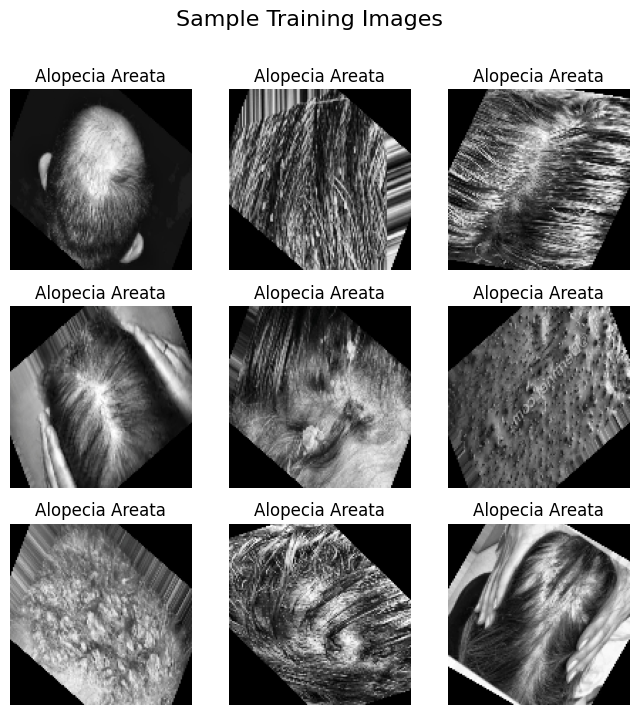

In [5]:
# ==============================
# 5️⃣ SHOW SAMPLE IMAGE
# ==============================
sample_images, sample_labels = next(train_gen)
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.title(train_gen.class_indices.keys().__iter__().__next__())
    plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=16)
plt.show()


In [6]:
# ==============================
# 6️⃣ CUSTOM ALEXNET MODEL
# ==============================
model = Sequential([
    Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    Conv2D(256, (5,5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(384, (3,3), padding='same', activation='relu'),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(3,3), strides=(2,2)),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

c:\CODING\AI\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# ==============================
# 7️⃣ TRAINING
# ==============================
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


c:\CODING\AI\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 88s 621ms/step - accuracy: 0.1341 - loss: 2.4549 - val_accuracy: 0.1356 - val_loss: 2.3413
Epoch 2/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 53s 382ms/step - accuracy: 0.1486 - loss: 2.3222 - val_accuracy: 0.1583 - val_loss: 2.2556
Epoch 3/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 72s 521ms/step - accuracy: 0.1605 - loss: 2.2715 - val_accuracy: 0.1902 - val_loss: 2.2531
Epoch 4/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 71s 512ms/step - accuracy: 0.1464 - loss: 2.2609 - val_accuracy: 0.1735 - val_loss: 2.2603
Epoch 5/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 68s 493ms/step - accuracy: 0.1777 - loss: 2.2494 - val_accuracy: 0.1682 - val_loss: 2.2595
Epoch 6/15
138/138 ━━━━━━━━━━━━━━━━━━━━ 65s 469ms/step - accuracy: 0.1659 - loss: 2.2497 - val_accuracy: 0.1576 - val_loss: 2.2658


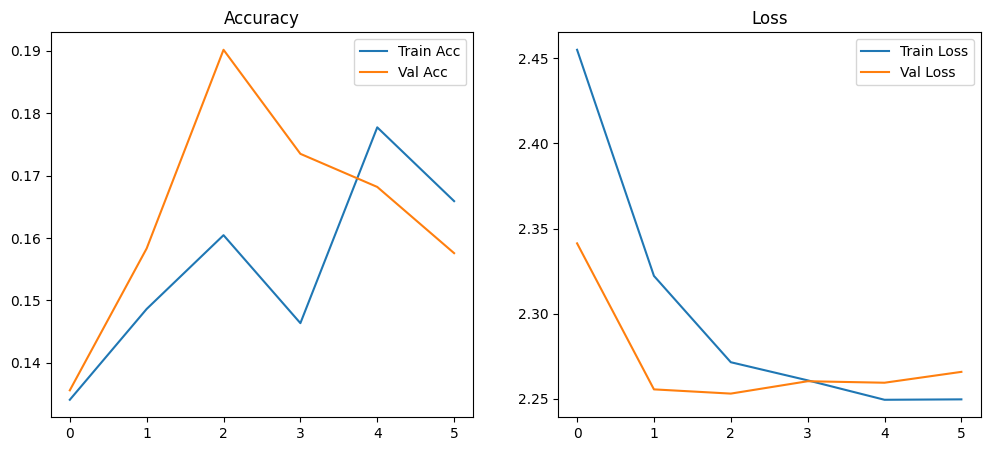

83/83 ━━━━━━━━━━━━━━━━━━━━ 36s 431ms/step - accuracy: 0.1712 - loss: 2.2460
Test Accuracy: 0.1712
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step
                       precision    recall  f1-score      support
Alopecia Areata         0.000000  0.000000  0.000000   120.000000
Contact Dermatitis      0.121359  0.208333  0.153374   120.000000
Folliculitis            0.118664  0.858333  0.208502   120.000000
Head Lice               0.000000  0.000000  0.000000   120.000000
Lichen Planus           0.000000  0.000000  0.000000   120.000000
Male Pattern Baldness   0.486339  0.741667  0.587459   120.000000
Psoriasis               0.000000  0.000000  0.000000   120.000000
Seborrheic Dermatitis   0.000000  0.000000  0.000000   120.000000
Telogen Effluvium       0.250000  0.058333  0.094595   120.000000
Tinea Capitis           0.068966  0.016667  0.026846   120.000000
healthy hair            0.000000  0.000000  0.000000   120.000000
accuracy                0.171212  0.171212  0.171212     0.171212
ma

c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\CODING\AI\venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


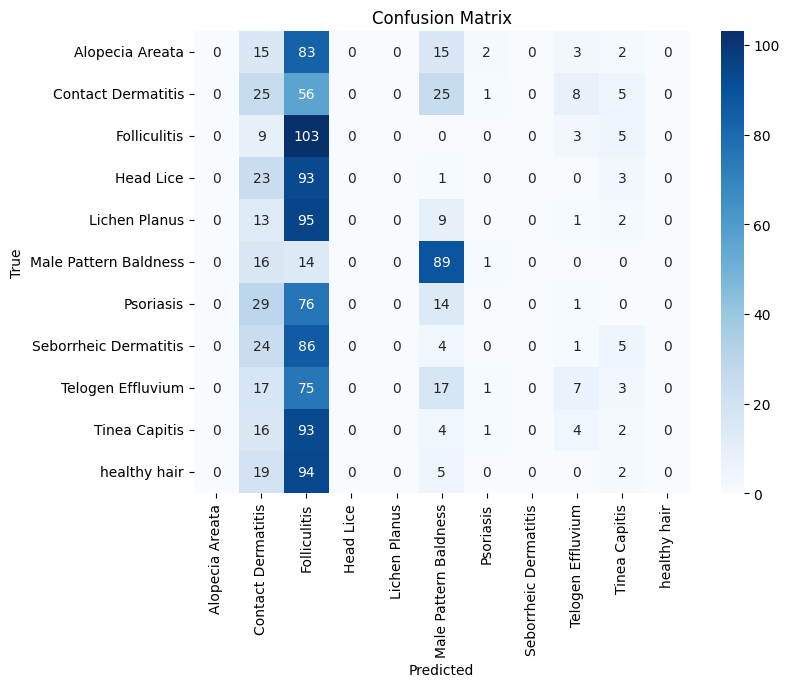

In [8]:
# ==============================
# 8️⃣ EVALUATION & PLOTS
# ==============================
# Accuracy/Loss Graphs
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()
plt.show()

# Test evaluation
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc:.4f}")

# Predictions
y_pred = np.argmax(model.predict(test_gen), axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()
print(df_report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [9]:
# ==============================
# 9️⃣ SAVE MODEL
# ==============================
model.save("alexnet_hair_disease_model.h5")